In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/superstore_cleaned.csv')

df['Order Date'] = pd.to_datetime(df['Order Date'])

print("Data loaded! Shape:", df.shape)
print("Columns:", df.columns.tolist())

Data loaded! Shape: (9994, 25)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month_Name', 'Delivery_Days']


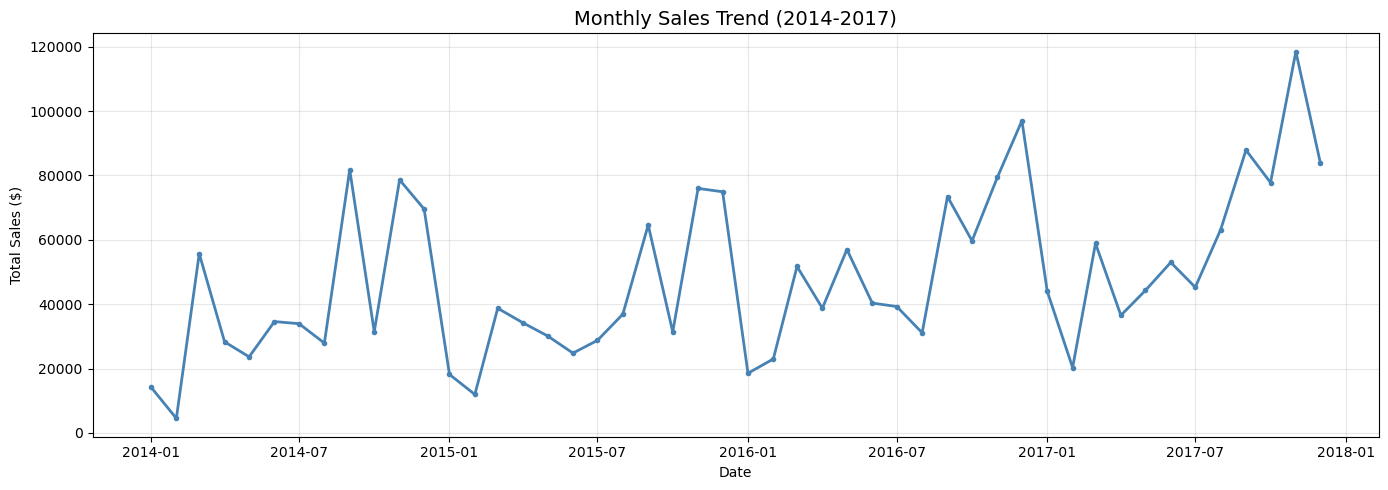

Chart saved!


In [2]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], 
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/monthly_sales_trend.png', dpi=150)
plt.show()
print("Chart saved!")

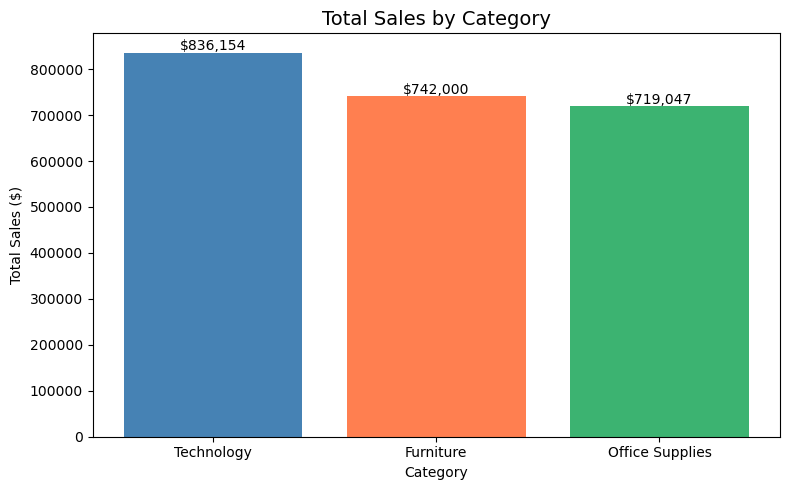

Chart saved!


In [3]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(category_sales.index, category_sales.values, 
               color=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Total Sales by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')

for bar, val in zip(bars, category_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/category_sales.png', dpi=150)
plt.show()
print("Chart saved!")

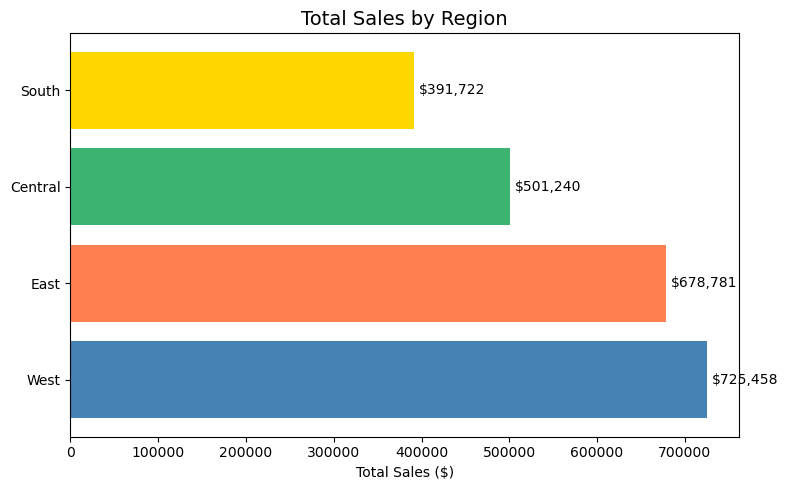

Chart saved!


In [4]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.barh(region_sales.index, region_sales.values,
                color=['steelblue', 'coral', 'mediumseagreen', 'gold'])
plt.title('Total Sales by Region', fontsize=14)
plt.xlabel('Total Sales ($)')

for bar, val in zip(bars, region_sales.values):
    plt.text(val + 5000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/region_sales.png', dpi=150)
plt.show()
print("Chart saved!")

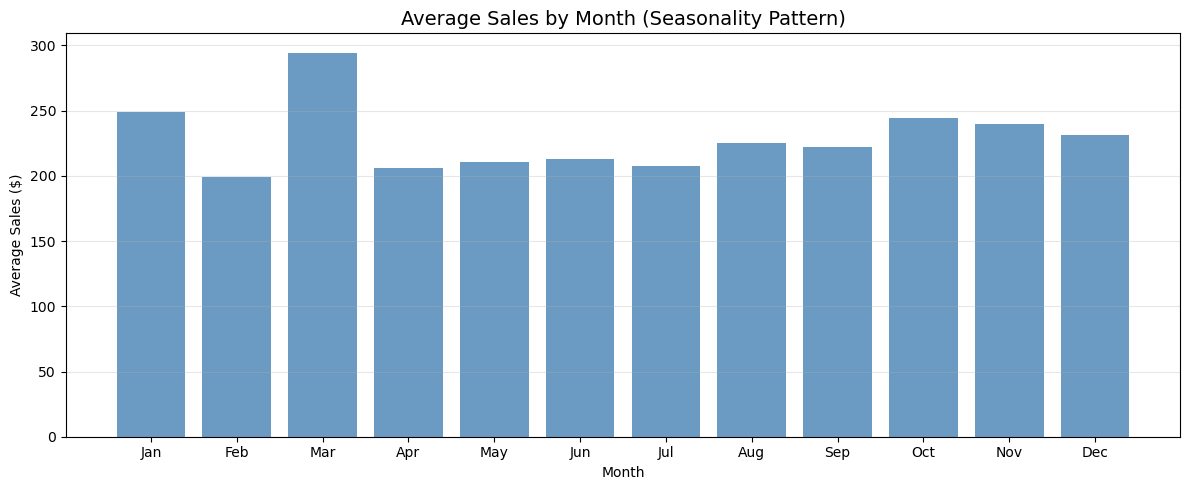

Chart saved!


In [5]:
monthly_avg = df.groupby('Month')['Sales'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
plt.bar(months, monthly_avg.values, color='steelblue', alpha=0.8)
plt.title('Average Sales by Month (Seasonality Pattern)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Sales ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/seasonality_pattern.png', dpi=150)
plt.show()
print("Chart saved!")

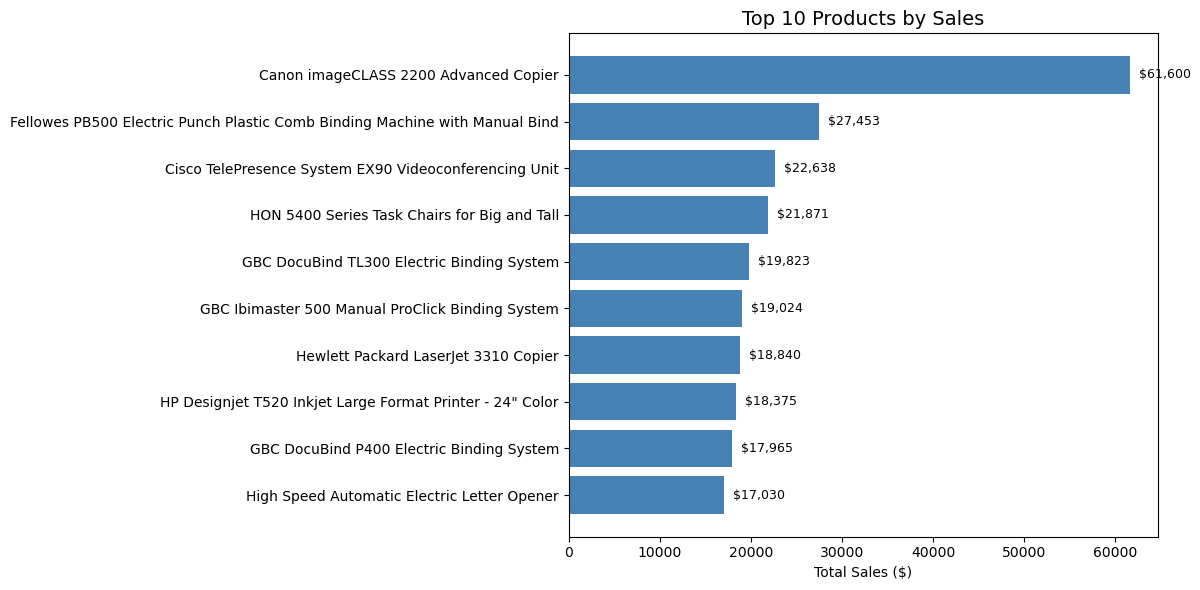

Chart saved!


In [6]:
top_products = df.groupby('Product Name')['Sales'].sum()\
                 .sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_products.index, top_products.values, color='steelblue')
plt.title('Top 10 Products by Sales', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.gca().invert_yaxis()

for bar, val in zip(bars, top_products.values):
    plt.text(val + 1000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/top10_products.png', dpi=150)
plt.show()
print("Chart saved!")

In [7]:
category_analysis = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).round(2)

category_analysis['Profit_Margin_%'] = (
    category_analysis['Total_Profit'] / 
    category_analysis['Total_Sales'] * 100
).round(2)

print(category_analysis)
print("\n🔍 Key Insight:")
for cat in category_analysis.index:
    margin = category_analysis.loc[cat, 'Profit_Margin_%']
    print(f"  {cat}: {margin:.1f}% profit margin")

                 Total_Sales  Total_Profit  Profit_Margin_%
Category                                                   
Furniture          741999.80      18451.27             2.49
Office Supplies    719047.03     122490.80            17.04
Technology         836154.03     145454.95            17.40

🔍 Key Insight:
  Furniture: 2.5% profit margin
  Office Supplies: 17.0% profit margin
  Technology: 17.4% profit margin


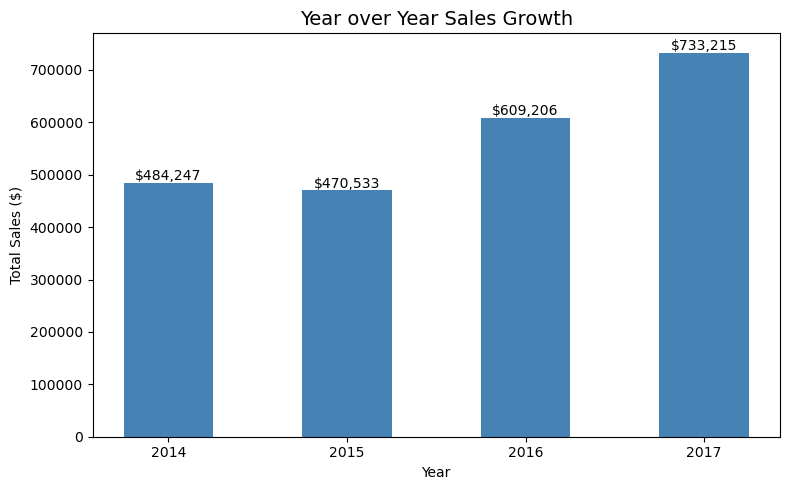

Chart saved!


In [8]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8, 5))
bars = plt.bar(yearly_sales.index.astype(str), yearly_sales.values, 
               color='steelblue', width=0.5)
plt.title('Year over Year Sales Growth', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')

for bar, val in zip(bars, yearly_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/yearly_growth.png', dpi=150)
plt.show()
print("Chart saved!")

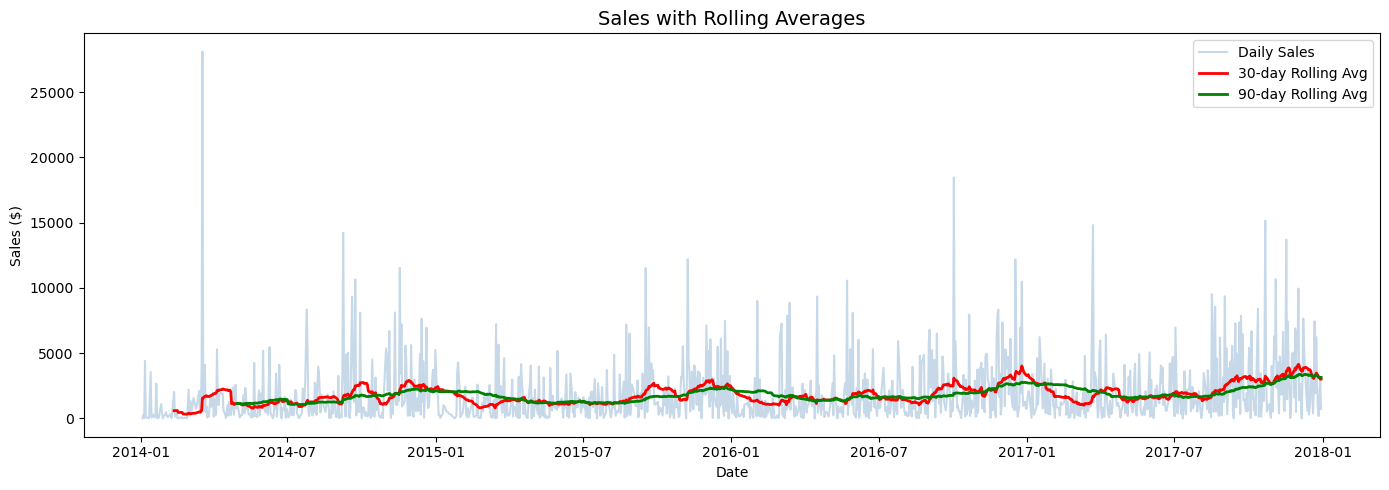

Chart saved!


In [9]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values, 
         alpha=0.3, color='steelblue', label='Daily Sales')
plt.plot(daily_sales.rolling(30).mean(), 
         color='red', linewidth=2, label='30-day Rolling Avg')
plt.plot(daily_sales.rolling(90).mean(), 
         color='green', linewidth=2, label='90-day Rolling Avg')

plt.title('Sales with Rolling Averages', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/rolling_averages.png', dpi=150)
plt.show()
print("Chart saved!")

In [10]:
print("=== 02_DEMAND_ANALYSIS SUMMARY ===")
print(f"Charts created: 6 (saved in outputs/ folder)")
print(f"\nTop Category by Sales: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Top Region by Sales: {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Top Product: {df.groupby('Product Name')['Sales'].sum().idxmax()}")
print(f"Peak Sales Month: {df.groupby('Month')['Sales'].mean().idxmax()}")
print(f"Best Year: {df.groupby('Year')['Sales'].sum().idxmax()}")
print(f"\nCharts saved:")
print("  - monthly_sales_trend.png")
print("  - category_sales.png")
print("  - region_sales.png")
print("  - seasonality_pattern.png")
print("  - top10_products.png")
print("  - yearly_growth.png")
print("  - rolling_averages.png")

=== 02_DEMAND_ANALYSIS SUMMARY ===
Charts created: 6 (saved in outputs/ folder)

Top Category by Sales: Technology
Top Region by Sales: West
Top Product: Canon imageCLASS 2200 Advanced Copier
Peak Sales Month: 3
Best Year: 2017

Charts saved:
  - monthly_sales_trend.png
  - category_sales.png
  - region_sales.png
  - seasonality_pattern.png
  - top10_products.png
  - yearly_growth.png
  - rolling_averages.png
